<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/iui2026-xai/Feature_based_xai_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blockies Dataset

This notebook download the blockies dataset and the corresponding trained model.  This is then used to evaluate the model on all datasets.  

Additionally, we provide a review of the various Blocky traits, to review the distributions between ill and healthy Blockies.

In [1]:
colab = False

if colab:
  %pip install shap -q

In [2]:
import os
from pathlib import Path
import tarfile
import random
import zipfile

import numpy as np

import pandas as pd

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image

import matplotlib.pyplot as plt

import shap
torch.backends.cudnn.benchmark = True

In [3]:
if colab:
  from google.colab import drive
  drive.mount('/content/drive')

  gdrive = Path('/content/drive/MyDrive/')

In [4]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18'

ds = 'main_blockies/default'
eval_ds = 'main_blockies/highvar'

random_state = 42

output_folder = gdrive / 'hcxai_studies/xai_study1/xai_samples/saliency_xai2' if colab else Path('output/xai_samples/saliency_xai2')
(output_folder / 'main_data').mkdir(parents=True, exist_ok=True)
(output_folder / 'tmp').mkdir(parents=True, exist_ok=True)
(output_folder / 'tutorial_data').mkdir(parents=True, exist_ok=True)

# Setup and Load Datasets

In [5]:
# data downloading and dataset utilities
def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

In [6]:
class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

## Load Dataset and Dataloaders


In [7]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [9]:
# download data direcly from sciebo

data_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

data_dir = download_file(url=data_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='/content/data' if colab else 'data', # change this if not using Colab
                          extract=True,
                          force_download=False,
                          archive_folder=zip_name)
data_dir

File already exists at: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [10]:
# load and preprocess dataframes
main_dir = data_dir / 'main_data/xai_samples'
tutorial_dir = data_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})


In [11]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

num_workers = 0

study_dataset = ImageDataset(study_df, main_dir, transform=transform)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

tutorial_dataset = ImageDataset(tutorial_df, tutorial_dir, transform=transform)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

# Model Loading and Evaluation





In [12]:
def load_mobilenetv2(num_classes, pretrained=True, checkpoint_path=None):
  """Loads a MobileNetV2 model, optionally loading from a checkpoint.

  Args:
    num_classes: The number of output classes.
    pretrained: Whether to load the pre-trained weights.
    checkpoint_path: Path to a checkpoint file to load.

  Returns:
    A MobileNetV2 model.
  """
  model = models.mobilenet_v2(weights=None if not pretrained else 'DEFAULT')
  model.classifier[1] = nn.Linear(model.last_channel, num_classes)

  if checkpoint_path:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
            model.load_state_dict(checkpoint["state_dict"], strict=False)
    else:
            model.load_state_dict(checkpoint, strict=False)
    print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [13]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [14]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/J2d1z9V5wQGGR8X/download',
                                file_name='best_model.pth',
                                cache_dir='checkpoint/resnet18_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=True)
checkpoint_path

  0%|          | 0.00/42.7M [00:00<?, ?B/s]

File downloaded to: checkpoint/resnet18_checkpoint/best_model.pth


PosixPath('checkpoint/resnet18_checkpoint/best_model.pth')

In [15]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [16]:
# — Helper functions for SHAP pipeline —
from PIL import Image
import numpy as np

def load_image(fp: str) -> np.ndarray:
    img = Image.open(fp).convert("RGB")
    return np.array(img) / 255

def preprocess(img: np.ndarray) -> np.ndarray:
    norm_img = (img - mean) / std
    return norm_img


## Evaluate Model

In [17]:
# — Cell A: instantiate model + wrap predict for SHAP

# load best model and evaluate
model = load_resnet18(num_classes=len(CLASSES),
                         pretrained=False,
                         checkpoint_path=checkpoint_path)
model.to(device)

_, _, study_preds = evaluate_model(model, study_dataloader, criterion, device)
_, _, tutorial_preds = evaluate_model(model, tutorial_dataloader, criterion, device)


Loaded random model
Loaded checkpoint from: checkpoint/resnet18_checkpoint/best_model.pth
Evaluation Loss: 0.6062, Evaluation Accuracy: 0.8000
Evaluation Loss: 0.9990, Evaluation Accuracy: 0.6000


In [18]:
print('Study Acc:', (study_df['ill'] == study_df['pred']).mean())
print('Tutorial Acc:', (tutorial_df['ill'] == tutorial_df['pred']).mean())

Study Acc: 0.8
Tutorial Acc: 0.6


# Generate Explanations

## Implemenations

In [19]:
import matplotlib as mpl
def combine_and_save(img, attribution, alpha, filter_perc, filename, cmap='seismic'):

    mask_neg = attribution < 0
    neg_rel = abs(attribution) * mask_neg
    thresh_neg = torch.quantile(neg_rel.flatten(), filter_perc)
    mask_neg = neg_rel > thresh_neg

    mask_pos = attribution > 0
    pos_rel = attribution * mask_pos
    thresh_pos = torch.quantile(pos_rel.flatten(), filter_perc)
    mask_pos = pos_rel > thresh_pos

    attribution = attribution * (mask_neg | mask_pos)

    vmax = attribution.abs().max()
    grayscale_img = np.dot(img[..., :3] * 255, [0.2989, 0.5870, 0.1140])

    cmap = plt.get_cmap(cmap)
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax, clip=False)
    heatmap_colored = cmap(norm(attribution))[:, :, :3] # Take only RGB channels

    # Convert grayscale image to RGB
    grayscale_rgb = np.stack([grayscale_img] * 3, axis=-1)

    # Combine the grayscale image and the colored heatmap
    # You can adjust the alpha value for the heatmap overlay
    combined_img_np = (grayscale_rgb * (1 - alpha) + heatmap_colored * 255 * alpha).astype(np.uint8)

    # Convert to PIL Image and save
    combined_img_pil = Image.fromarray(combined_img_np)
    combined_img_pil.save(filename)

    return combined_img_pil

In [20]:
def get_trait_mapping(traits):
    # Final simple remapping
    mapped_traits = []
    for trait in traits:
        trait = trait.strip()
        if "mutation_color" in trait.lower():
                continue
        if trait in ["high_bend", "med_bend"]:
            if "Strong Spine Bend" not in mapped_traits:
                mapped_traits.append("Strong Spine Bend")

        elif trait in ["high_sphere_diff", "med_sphere_diff"]:
            if "Strong Bone Variations" not in mapped_traits:
                mapped_traits.append("Strong Bone Variation")

        elif trait == "mutation_mainbones":
            if "Main Bone Mutation" not in mapped_traits:
                mapped_traits.append("Main Bones Mutation")

        elif trait == "stretchy":
                    if "Tucked Head" not in mapped_traits:
                        mapped_traits.append("Tucked Head")
        else:
            mapped_traits.append(trait)
    return mapped_traits

#### Shap

In [21]:
# Setup SHAP for Explaining Predictions

def predict_nhwc(x):
    t = torch.from_numpy(np.stack(x)).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        p = torch.nn.functional.softmax(model(t), 1).cpu().numpy()
    return p


def generate_shap_heatmap(image, class_idx, max_evals=500, pred_fn=predict_nhwc):

    # setup shap explainer
    masker = shap.maskers.Image("blur(128,128)", image.shape)
    explainer = shap.Explainer(pred_fn, masker, max_evals=max_evals)

    # preprocess image
    img_norm = preprocess(image)

    # get prediction
    probs     = predict_nhwc([img_norm])[0]
    pred_cls  = int(np.argmax(probs))

    # validate that shap function is making same predictions as original model
    assert class_idx == pred_cls, "Class index should match predicted class"

    # Get SHAP values
    exp = explainer(img_norm[np.newaxis, ...])

    # Select predicted class correctly from SHAP output
    if exp.values.ndim == 5:
        values = exp.values[0, ..., class_idx]  # shape (H, W, C)
    elif exp.values.ndim == 4:
        values = exp.values[class_idx]          # fallback
    elif exp.values.ndim == 3:
        values = exp.values                    # already fine
    else:
        print(f"Skipping image: unknown SHAP shape {exp.values.shape}")
        return None

    # Collapse to 2D: signed importance
    heatmap = values.sum(axis=-1)  # shape (H, W)

    return heatmap

### LRP

In [22]:
from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonPlusFlat, EpsilonAlpha2Beta1Flat # EpsilonPlusFlat

In [28]:
def generate_lrp_heatmap(image, class_idx, model=model):

    inp = transform(image).unsqueeze(0)

    target = torch.zeros(len(CLASSES), dtype=torch.float)
    target[class_idx] = 1.0
    target = target.unsqueeze(0)

    with Gradient(model=model, composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attributor:
      inp = inp.to(torch.float).to('cpu')
      output, attribution = attributor(inp, target)

    return attribution.squeeze().permute(1,2,0).numpy().sum(axis=-1) # LRP heatmap summed to one channel

## Study Study

In [29]:
# max_evals = 2500

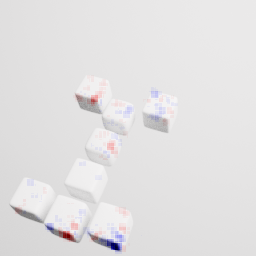

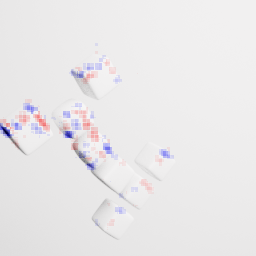

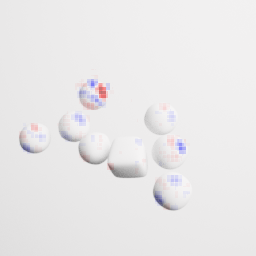

In [ ]:
# Final Output Loop
for i, (idx, row) in enumerate(study_df.iterrows()):

    image_id = row['id']
    image = load_image(main_dir / row['filename'])
    class_idx = row['pred']

    # hm = generate_shap_heatmap(image, class_idx, max_evals=max_evals)
    hm = generate_lrp_heatmap(image, class_idx)
    final_hm = combine_and_save(torch.from_numpy(image), torch.from_numpy(hm), alpha=0.5, filter_perc=0.975,
                                filename=output_folder / 'tmp' / f'{image_id}_saliency.png', cmap='seismic')
    # display(final_hm)

In [ ]:
#CSV Generation

CLASSES = ['Healthy', 'OCDegen']

# Random X-ray locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]

# Create rows
rows = []
for idx, (idx, row) in enumerate(study_df.iterrows()):
    pred_label = CLASSES[row['pred']]
    true_label = CLASSES[row["ill"]]

    # get traits for tutorial
    try:
        traits = ast.literal_eval(row["ill_chars"]) if isinstance(row["ill_chars"], str) else row["ill_chars"]
    except:
        traits = []
    mapped_traits = get_trait_mapping(traits)
    caption = ", ".join(mapped_traits)
    if not caption:
        caption = "No Trait"

    # Compose row
    rows.append({
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": f"{row['id']}.png",
        "TRUE_DIAG": true_label,
        "SUGGESTED_DIAG": pred_label,
        "Shap": f"{row['id']}_saliency.png",
        "Shap_Caption": caption,
        "X_RAY_LOCATION": random.choice(locations)
    })

# Build final DataFrame
df = pd.DataFrame(rows)


# Reorder columns
df = df[[
    "PATIENT_ID", "X_RAY_IMAGE", "TRUE_DIAG", "SUGGESTED_DIAG",
    "Shap", "Shap_Caption", "X_RAY_LOCATION"
]]

# Save to CSV
csv_path = output_folder / "main_data/input_saliency.csv"
df.to_csv(csv_path, index=False)
print(f"input_saliency.csv saved to: {csv_path}")


In [ ]:
#Zipfile
zip_filename = output_folder / "main_data/study_images_example.zip"

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

shap_files = pd.unique(df['Shap'].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in shap_files:
        img_path = output_folder / 'tmp' / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = main_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(shap_files) + len(main_files)} images to {zip_filename}")

In [ ]:
df

## Tutorial Data

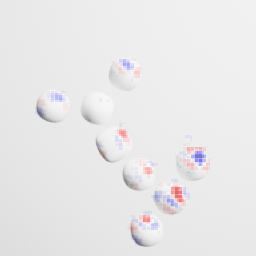

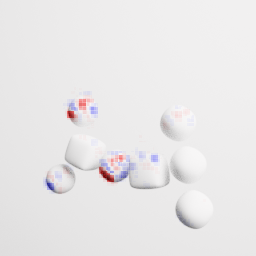

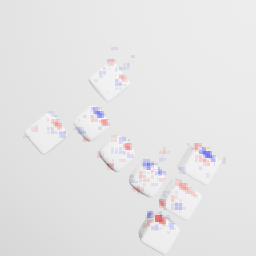

In [ ]:
# Final Output Loop
for i, (idx, row) in enumerate(tutorial_df.iterrows()):

    image_id = row['id']
    image = load_image(tutorial_dir / row['filename'])
    class_idx = row['pred']

    # hm = generate_shap_heatmap(image, class_idx, max_evals=max_evals)
    hm = generate_lrp_heatmap(image, class_idx)
    final_hm = combine_and_save(torch.from_numpy(image), torch.from_numpy(hm), alpha=0.5, filter_perc=0.975,
                                filename=output_folder / 'tmp' / f'{image_id}_saliency.png', cmap='seismic')
    # display(final_hm)

In [ ]:
#CSV Generation

CLASSES = ['Healthy', 'OCDegen']

# Random X-ray locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]

# Create rows
rows = []
for idx, (idx, row) in enumerate(tutorial_df.iterrows()):
    pred_label = CLASSES[row['pred']]
    true_label = CLASSES[row["ill"]]

    # get traits for tutorial
    try:
        traits = ast.literal_eval(row["ill_chars"]) if isinstance(row["ill_chars"], str) else row["ill_chars"]
    except:
        traits = []
    mapped_traits = get_trait_mapping(traits)
    caption = ", ".join(mapped_traits)
    if not caption:
        caption = "No Trait"

    # Compose row
    rows.append({
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": f"{row['id']}.png",
        "TRUE_DIAG": true_label,
        "SUGGESTED_DIAG": pred_label,
        "Shap": f"{row['id']}_saliency.png",
        "Shap_Caption": caption,
        "X_RAY_LOCATION": random.choice(locations)
    })

# Build final DataFrame
df = pd.DataFrame(rows)


# Reorder columns
df = df[[
    "PATIENT_ID", "X_RAY_IMAGE", "TRUE_DIAG", "SUGGESTED_DIAG",
    "Shap", "Shap_Caption", "X_RAY_LOCATION"
]]

# Save to CSV
csv_path = output_folder / "tutorial_data/input_saliency.csv"
df.to_csv(csv_path, index=False)
print(f"input_saliency.csv saved to: {csv_path}")


In [ ]:
#Zipfile
zip_filename = output_folder / "tutorial_data/study_images_example.zip"

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

shap_files = pd.unique(df['Shap'].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in shap_files:
        print(f"Adding SHAP image: {output_folder / 'tmp' / img_name}")
        img_path = output_folder / 'tmp' / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = tutorial_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(shap_files) + len(main_files)} images to {zip_filename}")

In [ ]:
df